In [1]:
library(tidyverse)
library(corrplot)
library(ppcor)
library(astsa)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded

Loading required package: MASS


Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select


Warning message:
"package 'astsa' was built under R version 4.5.3"


## Duomenys

In [2]:
data <- read.csv(file.path("..", "..", "python", "datasets_prep", "dm_project_dataset_alpha.csv"), sep = ',')
data$time <- as.Date(data$time)
dim(data)

[1] 2772   31

In [3]:
head(data, 5)

,time,airTemperature,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,⋯,O3_Error,dust,sia,pm2p5,pans,nmvoc,nh3,pm10,tp,t2m
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-07-01,11.29583,1010.638,72.79167,9.100000e+00,89.37500,10.93333,3.762500,13.9,356,⋯,0.8230156,0.01145233,0.4123398,1.127883,1.174715,2.292138,0.1059741,1.338105,14.6533580000,12.97028
2,2018-07-02,10.86667,1006.663,94.00000,1.190000e+01,91.50000,10.42917,2.516667,7.0,327,⋯,0.7565302,0.01151537,0.9462600,1.609913,1.935448,3.792921,0.1984277,1.752331,6.4759570000,14.77985
3,2018-07-03,13.38750,1008.454,90.04167,1.000000e+01,89.37500,13.38750,2.537500,8.3,271,⋯,1.6245888,0.04419387,0.6769881,1.534471,1.787800,2.332084,0.1188589,1.789138,9.6073170000,15.96597
4,2018-07-04,13.59167,1009.237,88.29167,1.390000e+01,88.33333,13.59167,2.358333,8.7,288,⋯,0.7592764,0.12872760,0.8331606,3.229130,1.201320,2.113538,0.3611570,4.323638,0.0133075710,18.01572
5,2018-07-05,16.29167,1008.079,70.20833,2.220446e-16,66.00000,16.29167,1.283333,6.1,293,⋯,0.8920967,0.09764995,0.7374821,2.768797,1.206750,2.267631,0.3165334,3.718909,-0.0007406473,19.04031


In [4]:
colnames(data)

[1] "time"                                   
 [2] "airTemperature"                         
 [3] "seaLevelPressure"                       
 [4] "relativeHumidity"                       
 [5] "xgb_precipitation"                      
 [6] "xgb_cloudCover"                         
 [7] "feelsLikeTemperature_fixed"             
 [8] "windSpeed_fixed"                        
 [9] "windGust_fixed"                         
[10] "windDirection_fixed"                    
[11] "absorbing_aerosol_index"                
[12] "NO2_column_number_density"              
[13] "stratospheric_NO2_column_number_density"
[14] "NO2_slant_column_number_density"        
[15] "tropopause_pressure"                    
[16] "H2O_column_number_density"              
[17] "BrO"                                    
[18] "BrO_Error"                              
[19] "NO2"                                    
[20] "NO2_Error"                              
[21] "O3"                                     
[22] "O3_Error"                               
[23] "dust"                                   
[24] "sia"                                    
[25] "pm2p5"                                  
[26] "pans"                                   
[27] "nmvoc"                                  
[28] "nh3"                                    
[29] "pm10"                                   
[30] "tp"                                     
[31] "t2m"

Visi duomenys išskyrus taršos rodiklių paklaidas

In [5]:
data_clean <- data %>%
    mutate(tp_lag = lag(tp, 1)) %>%
    mutate(tp_error = abs(tp_lag - xgb_precipitation)) %>%
    dplyr::select(-c('BrO_Error', 'NO2_Error', 'O3_Error')) %>%
    na.omit()

In [6]:
dim(data_clean)

[1] 2740   30

## Oro taršos elementų įtaką kritulių prognozavimo tikslumui

### Paklaidos kiekvienai dienai

In [7]:
x <- data_clean %>%
    dplyr::select(where(is.numeric)) %>%
    dplyr::select(-xgb_precipitation, -tp, -t2m, -tp_lag, -tp_error)

cor_rez_day <- cor(x, data_clean$tp_error, use = "complete.obs", method = "spearman") 
cor_rez_day

airTemperature,0.03423421
seaLevelPressure,-0.47969376
relativeHumidity,0.37247224
xgb_cloudCover,0.44153782
feelsLikeTemperature_fixed,0.01959019
windSpeed_fixed,0.18394812
windGust_fixed,0.25122201
windDirection_fixed,0.04429000
absorbing_aerosol_index,-0.04280264
NO2_column_number_density,0.02990270
stratospheric_NO2_column_number_density,0.04560268


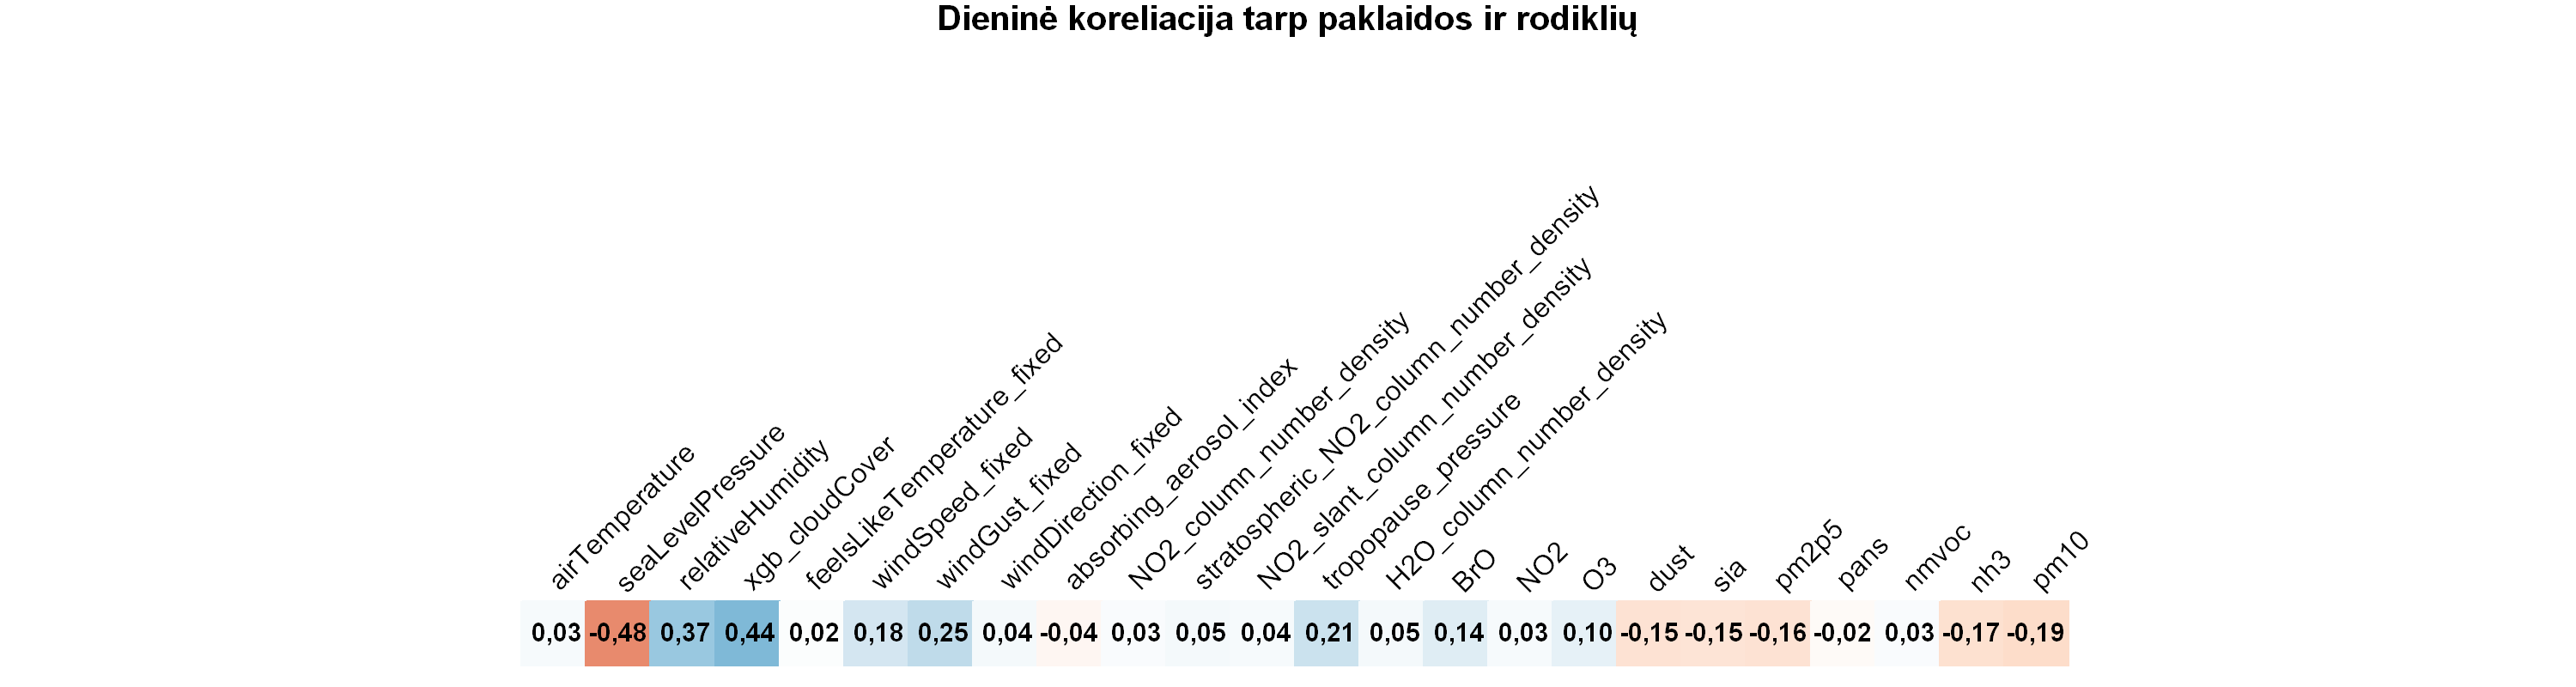

In [8]:
options(repr.plot.width = 15, repr.plot.height = 4, repr.plot.res = 200)

plot_corr_1 <- as.matrix(t(cor_rez_day))
rownames(plot_corr_1) <- ""

# png(filename = "corr_heatmap_1.png", width = 17, height = 4.5, units = "in", res = 300)

options(OutDec = ",")
corrplot(plot_corr_1, method = 'color', addCoef.col = "black", tl.srt = 45, tl.col = 'black', tl.pos = 't', number.cex = 0.9, cl.pos = 'n', title = "Dieninė koreliacija tarp paklaidos ir rodiklių", mar = c(0,0,1,0))
options(OutDec = ".")

# dev.off()

In [9]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

col_names <- c(
  "airTemperature" = "Oro temperatūra",
  "seaLevelPressure" = "Slėgis jūros lygyje",
  "relativeHumidity" = "Santykinis oro drėgnis",
  "xgb_cloudCover" = "Debesuotumas",
  "feelsLikeTemperature_fixed" = "Juntamoji temperatūra",
  "windSpeed_fixed" = "Vėjo greitis",
  "windGust_fixed" = "Vėjo gūsis",
  "windDirection_fixed" = "Vėjo kryptis",
  "absorbing_aerosol_index" = "AAI",
  "NO2_column_number_density" = "NO2 VCD",
  "stratospheric_NO2_column_number_density" = "Stratosferos NO2 VCD",
  "NO2_slant_column_number_density" = "NO2 SCD",
  "tropopause_pressure" = "Tropopauzės slėgis",
  "H2O_column_number_density" = "H2O",
  "BrO" = "BrO VCD",
  "NO2" = "NO2 VCD",
  "O3" = "O3 VCD",
  "dust" = "Dulkės",
  "sia" = "PM2,5 SIA",
  "pm2p5" = "PM2,5",
  "pans" = "PAN",
  "nmvoc" = "NMVOC",
  "nh3" = "NH3",
  "pm10" = "PM10"
)

rownames(cor_rez_day) <- col_names

part1 <- as.matrix(cor_rez_day[1:8, , drop = FALSE])
part2 <- as.matrix(cor_rez_day[9:16, , drop = FALSE])
part3 <- as.matrix(cor_rez_day[17:24, , drop = FALSE])

colnames(part1) <- "Paklaida"; colnames(part2) <- "Paklaida"; colnames(part3) <- "Paklaida"

width_inch = 17 / 2.54
height_inch = width_inch * 0.7

png(filename = "corr_heatmap_1.png", width = width_inch, height = height_inch, units = "in", res = 300)
layout(matrix(c(1, 2, 3), 1, 3))
par(mfrow = c(1, 3), oma = c(0, 0, 4, 0))

options(OutDec = ",")

corrplot(part1, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex=1.2, tl.cex = 1.2, tl.offset = 1)
corrplot(part2, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex=1.2, tl.cex = 1.2, tl.offset = 1)
corrplot(part3, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex=1.2, tl.cex = 1.2, tl.offset = 1)

mtext("Koreliacija tarp dieninės ECMWF paklaidos ir rodiklių", side = 3, line = 2, outer = TRUE, cex = 1.1, font = 1)

par(mfrow = c(1, 1))
options(OutDec = ".")

dev.off()

agg_record_1777630595 
                    2

### Paklaidos mėnesiui

In [10]:
data_by_month <- data_clean %>%
    dplyr::select(-t2m, -tp, -tp_lag) %>%
    group_by(year = year(time), month = month(time)) %>%
    summarise(across(where(is.numeric), ~mean(., na.rm = TRUE)), .groups = "drop")
head(data_by_month)

year,month,airTemperature,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,⋯,NO2,O3,dust,sia,pm2p5,pans,nmvoc,nh3,pm10,tp_error
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2018,7,19.782222,1011.621,77.39444,3.6733333,61.43400,19.83361111,1.985833,9.106667,⋯,3.871693e+15,325.8890,1.06237442,1.548626,4.601026,1.6584937,3.585722,0.19122389,5.652042,2.6259764
2018,8,19.148656,1016.927,71.29839,1.7419355,41.00312,19.12238514,2.005951,9.129032,⋯,3.439835e+15,304.8510,0.09325709,2.258098,4.798764,1.6170481,3.150768,0.51960494,6.347528,2.7505494
2018,9,14.635694,1018.335,73.81667,1.1200000,50.09821,14.21180556,2.285833,9.126667,⋯,2.787817e+15,297.2015,2.23112997,3.133960,7.357725,1.4149473,3.261975,0.60311948,11.413385,1.0562787
2018,10,8.083360,1017.771,82.20124,1.3290323,50.89922,6.73062903,2.825586,9.354839,⋯,2.230254e+15,294.6680,0.29404332,3.243211,6.242818,1.0552586,3.197375,0.29334225,8.690252,0.5587336
2018,11,2.051250,1027.381,91.02778,0.5733333,86.08711,-0.05652778,2.671944,7.813333,⋯,1.624237e+15,310.4006,1.48851305,4.479328,8.132359,1.0289202,3.383899,0.07620617,10.514413,0.5433934
2018,12,-1.481586,1016.517,94.35215,2.3741935,94.00801,-4.78010753,2.848253,8.132258,⋯,1.390397e+15,318.7455,0.04485326,2.343671,4.724880,0.9796066,4.634385,0.02553789,6.197183,1.1422593


In [11]:
x_monthly <- data_by_month %>%
  dplyr::select(where(is.numeric)) %>%
  dplyr::select(-year, -month, -xgb_precipitation, -tp_error)

cor_rez_month <- cor(x_monthly, data_by_month$tp_error, use = "complete.obs", method = "spearman") 
cor_rez_month

airTemperature,0.63817755
seaLevelPressure,-0.49643166
relativeHumidity,-0.26474873
xgb_cloudCover,-0.26211466
feelsLikeTemperature_fixed,0.62899123
windSpeed_fixed,-0.40512821
windGust_fixed,0.02747676
windDirection_fixed,-0.06296251
absorbing_aerosol_index,-0.21201794
NO2_column_number_density,0.40926040
stratospheric_NO2_column_number_density,0.59968720


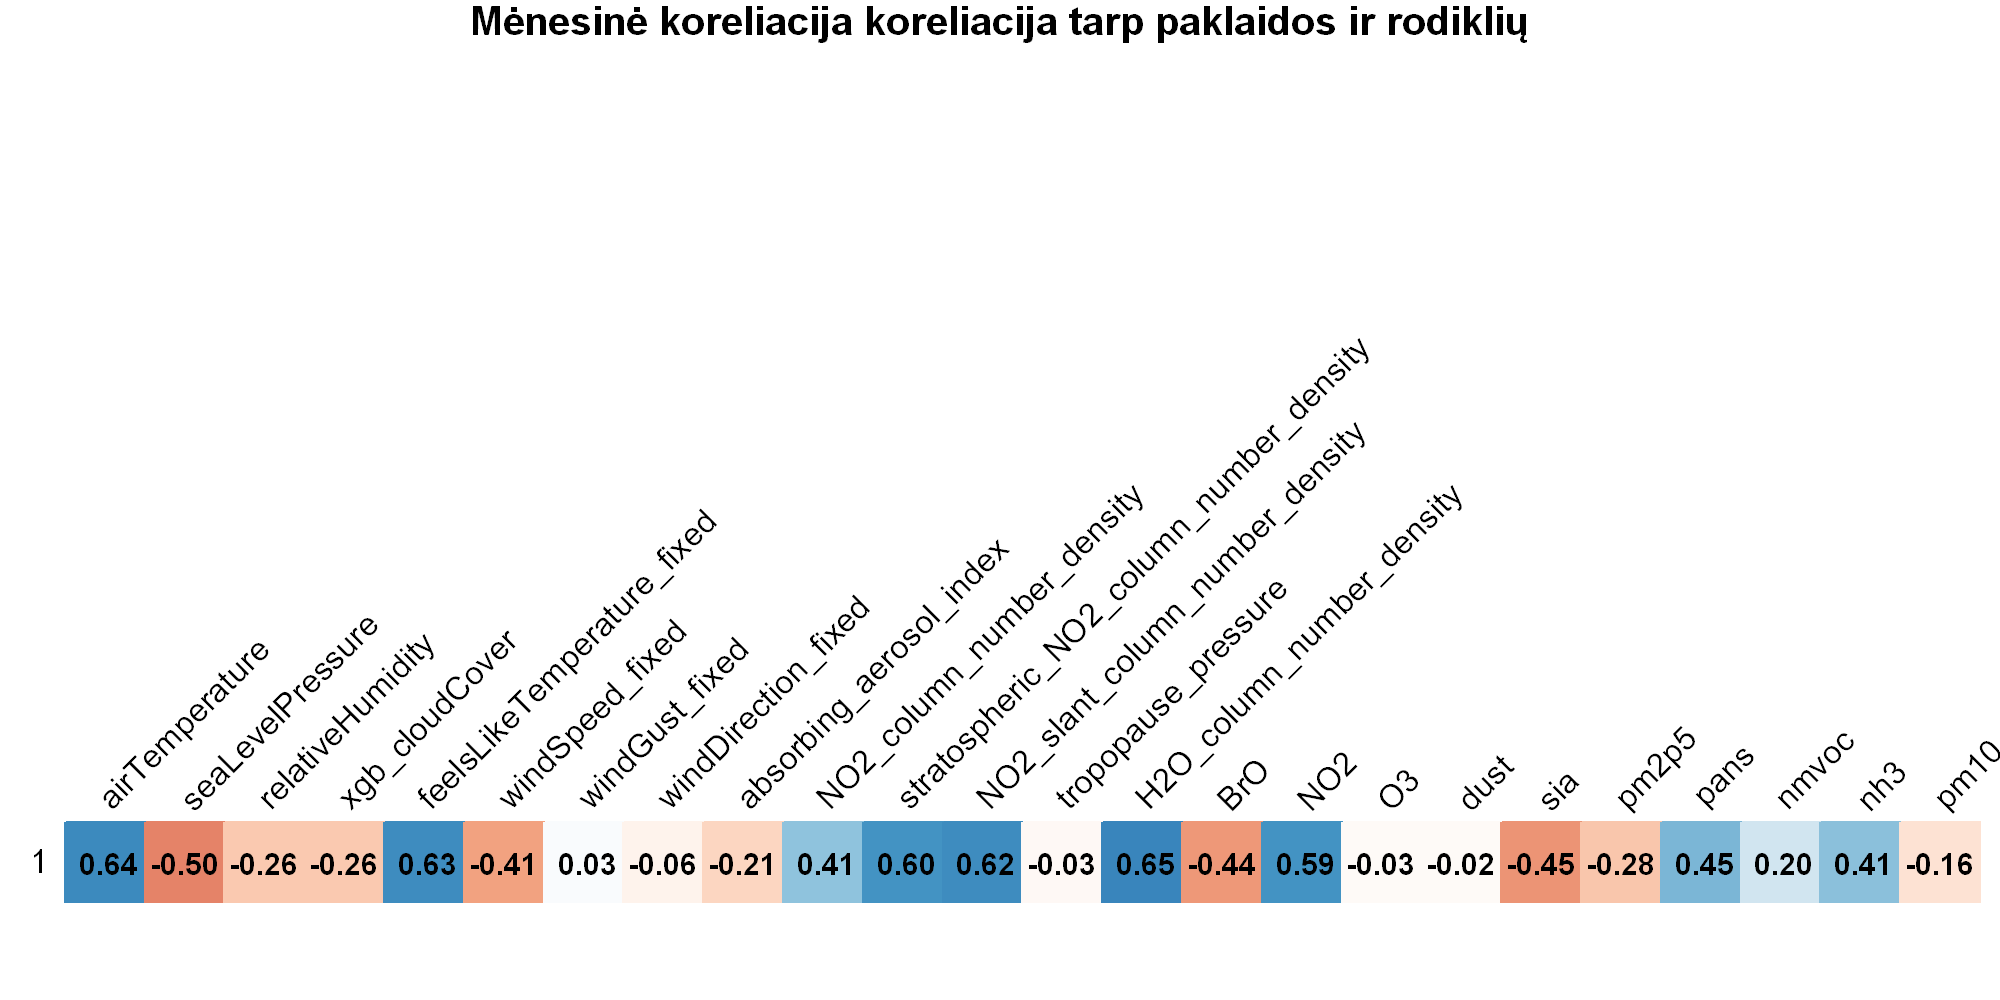

In [12]:
corrplot(t(cor_rez_month), method = 'color', addCoef.col = "black", tl.srt = 45, tl.col = 'black', number.cex = 0.9, cl.pos = 'n', title = "Mėnesinė koreliacija koreliacija tarp paklaidos ir rodiklių", mar = c(0,0,1,0))

## Koreliacija
### Koreliacija tarp visų kintamųjų

In [13]:
colnames(data_clean)

[1] "time"                                   
 [2] "airTemperature"                         
 [3] "seaLevelPressure"                       
 [4] "relativeHumidity"                       
 [5] "xgb_precipitation"                      
 [6] "xgb_cloudCover"                         
 [7] "feelsLikeTemperature_fixed"             
 [8] "windSpeed_fixed"                        
 [9] "windGust_fixed"                         
[10] "windDirection_fixed"                    
[11] "absorbing_aerosol_index"                
[12] "NO2_column_number_density"              
[13] "stratospheric_NO2_column_number_density"
[14] "NO2_slant_column_number_density"        
[15] "tropopause_pressure"                    
[16] "H2O_column_number_density"              
[17] "BrO"                                    
[18] "NO2"                                    
[19] "O3"                                     
[20] "dust"                                   
[21] "sia"                                    
[22] "pm2p5"                                  
[23] "pans"                                   
[24] "nmvoc"                                  
[25] "nh3"                                    
[26] "pm10"                                   
[27] "tp"                                     
[28] "t2m"                                    
[29] "tp_lag"                                 
[30] "tp_error"

In [14]:
numeric_columns <- data_clean %>%
    dplyr::select(where(is.numeric)) %>%
    dplyr::select(-tp, -tp_lag, -t2m, -tp_error)
    
corr <- cor(numeric_columns, use = "complete.obs", method = "spearman") 
View(corr)

,airTemperature,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,⋯,BrO,NO2,O3,dust,sia,pm2p5,pans,nmvoc,nh3,pm10
airTemperature,1.000000000,-0.07011217,-0.48866743,-0.08850799,-0.52000741,0.995723163,-0.29419845,-0.030016671,-0.10231347,-0.23501807,⋯,-0.48100637,0.777679021,-0.28715456,0.40119641,0.000935604,0.111479967,0.417113748,0.04901315,0.69731637,0.23273454
seaLevelPressure,-0.070112165,1.00000000,-0.18629078,-0.49055039,-0.24796456,-0.042456754,-0.30481738,-0.341364209,-0.07573255,0.05215469,⋯,-0.10133624,-0.086957334,-0.17881293,0.21629418,0.164188235,0.166398278,-0.018619961,-0.02641853,0.05238703,0.17785690
relativeHumidity,-0.488667433,-0.18629078,1.00000000,0.47618982,0.75301608,-0.488289387,0.13457637,-0.093782206,0.05348048,0.17082885,⋯,0.26040686,-0.597001735,-0.17367024,-0.22922719,0.011479656,-0.051698188,-0.387350632,0.15649722,-0.63623797,-0.18872668
xgb_precipitation,-0.088507991,-0.49055039,0.47618982,1.00000000,0.47359172,-0.104954223,0.22178875,0.268077924,0.05717727,0.01085012,⋯,0.18079589,-0.076552294,0.09347593,-0.28098428,-0.225648757,-0.248730591,-0.122154083,-0.02607150,-0.21604275,-0.28410863
xgb_cloudCover,-0.520007411,-0.24796456,0.75301608,0.47359172,1.00000000,-0.527078550,0.27347531,0.071792725,0.05285031,0.17656271,⋯,0.35226383,-0.541968118,0.05003032,-0.23827787,-0.044045147,-0.112788131,-0.328490108,0.11644746,-0.61562815,-0.23120337
feelsLikeTemperature_fixed,0.995723163,-0.04245675,-0.48828939,-0.10495422,-0.52707855,1.000000000,-0.35514553,-0.082644196,-0.11173470,-0.23392188,⋯,-0.48123652,0.782623598,-0.28679014,0.40781695,0.006584434,0.112628660,0.429213228,0.05570588,0.69808176,0.22928144
windSpeed_fixed,-0.294198449,-0.30481738,0.13457637,0.22178875,0.27347531,-0.355145534,1.00000000,0.808053689,0.20098492,0.08287336,⋯,0.18736609,-0.311860345,0.08917597,-0.19733020,-0.049033705,-0.060254366,-0.327000634,-0.13547974,-0.25058773,-0.04466577
windGust_fixed,-0.030016671,-0.34136421,-0.09378221,0.26807792,0.07179272,-0.082644196,0.80805369,1.000000000,0.17504963,-0.04419904,⋯,0.09349527,-0.011633902,0.15051891,-0.15279994,-0.163152389,-0.151179674,-0.155707464,-0.23947974,-0.01353561,-0.08920512
windDirection_fixed,-0.102313471,-0.07573255,0.05348048,0.05717727,0.05285031,-0.111734699,0.20098492,0.175049628,1.00000000,0.02090140,⋯,0.10629372,-0.049524523,0.11788419,-0.24726764,-0.226169335,-0.269812612,-0.187865627,-0.26247016,-0.02448508,-0.21564159
absorbing_aerosol_index,-0.235018071,0.05215469,0.17082885,0.01085012,0.17656271,-0.233921881,0.08287336,-0.044199037,0.02090140,1.00000000,⋯,0.03559666,-0.286524252,-0.07455678,-0.04028505,0.012922746,-0.070129761,-0.215233625,0.17529857,-0.18680466,-0.04542858


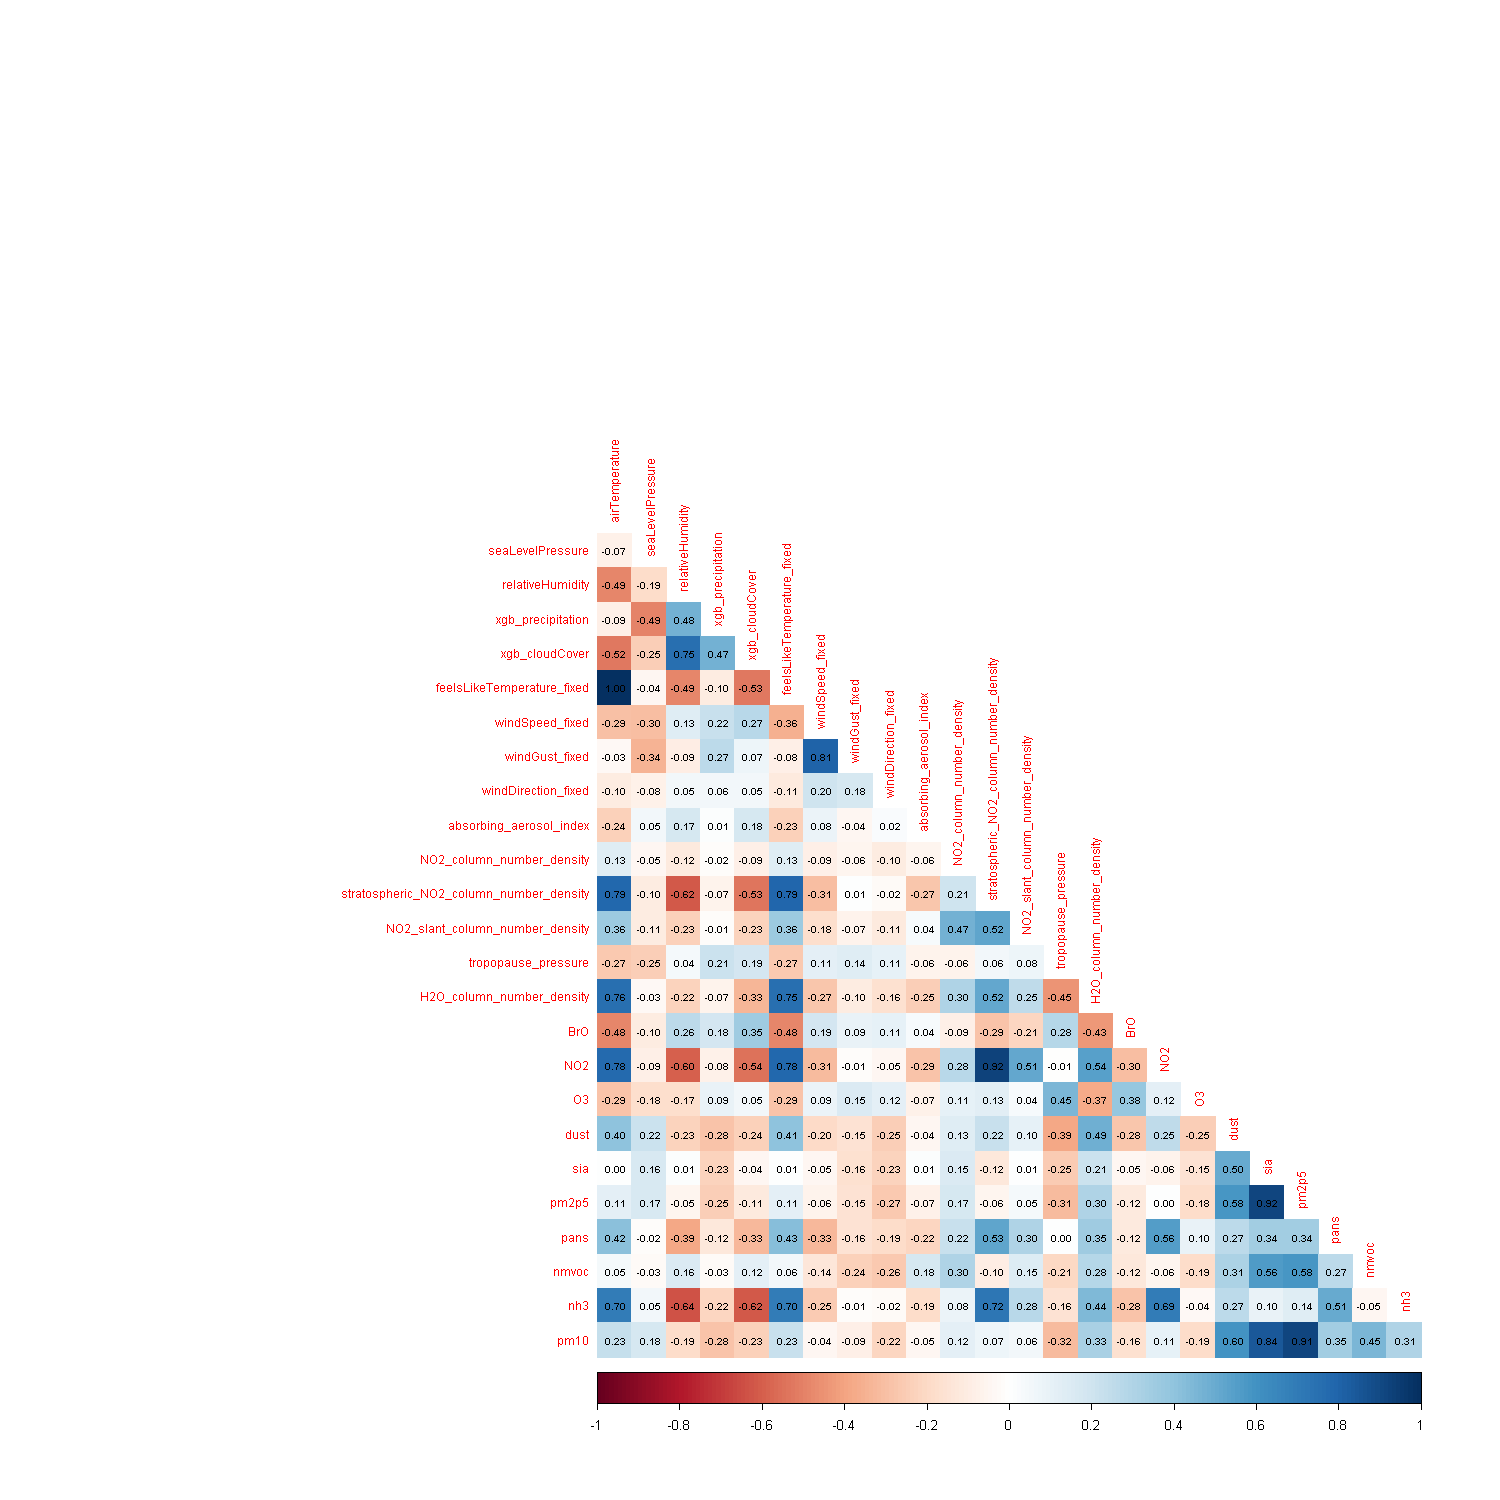

In [16]:
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 100)

corrplot(corr, method = "color", type = "lower",addCoef.col = "black", number.cex = 0.6, tl.cex = 0.7, diag = FALSE)

### Koreliacija tarp kritulių ir visų kintamųjų

In [17]:
x <- data_clean %>%
    dplyr::select(where(is.numeric)) %>%
    dplyr::select(-xgb_precipitation, -tp, -t2m, -tp_lag, -tp_error)

corr_xgb_precipitation <- cor(x, data_clean$xgb_precipitation, use = "complete.obs", method = "spearman") 
corr_xgb_precipitation

airTemperature,-0.08850799
seaLevelPressure,-0.49055039
relativeHumidity,0.47618982
xgb_cloudCover,0.47359172
feelsLikeTemperature_fixed,-0.10495422
windSpeed_fixed,0.22178875
windGust_fixed,0.26807792
windDirection_fixed,0.05717727
absorbing_aerosol_index,0.01085012
NO2_column_number_density,-0.01861512
stratospheric_NO2_column_number_density,-0.06533258


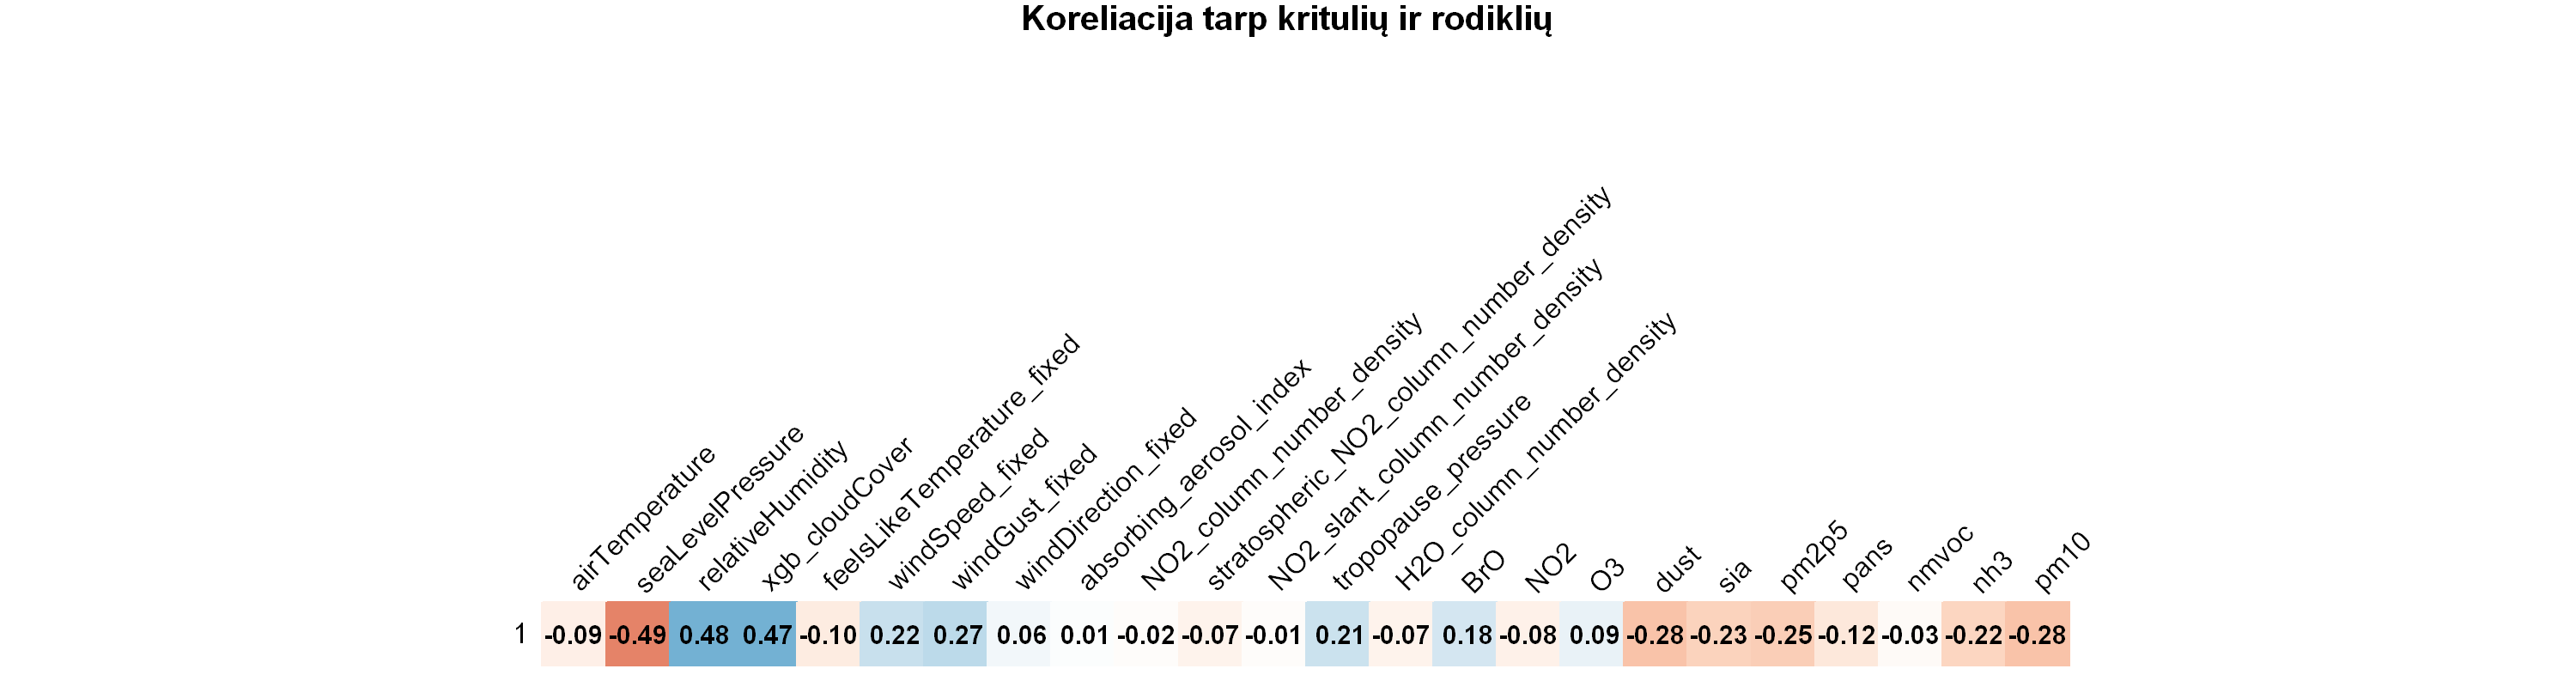

In [18]:
options(repr.plot.width = 15, repr.plot.height = 4, repr.plot.res = 200)
corrplot(t(corr_xgb_precipitation), method = 'color', addCoef.col = "black", tl.srt = 45, number.cex = 0.9, tl.col = 'black', cl.pos = 'n', title = "Koreliacija tarp kritulių ir rodiklių", mar = c(0,0,1,0))

In [19]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

width_inch = 17 / 2.54
height_inch = width_inch * 0.7

rownames(corr_xgb_precipitation) <- col_names

part1 <- as.matrix(corr_xgb_precipitation[1:8, , drop = FALSE])
part2 <- as.matrix(corr_xgb_precipitation[9:16, , drop = FALSE])
part3 <- as.matrix(corr_xgb_precipitation[17:24, , drop = FALSE])

colnames(part1) <- "Krituliai"; colnames(part2) <- "Krituliai"; colnames(part3) <- "Krituliai"

png(filename = "corr_heatmap_2.png", width = width_inch, height = height_inch, units = "in", res = 300)
layout(matrix(c(1, 2, 3), 1, 3))
par(mfrow = c(1, 3), oma = c(0, 0, 4, 0))

options(OutDec = ",")

corrplot(part1, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex=1.2, tl.cex = 1.2, tl.offset = 1)
corrplot(part2, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex=1.2, tl.cex = 1.2, tl.offset = 1)
corrplot(part3, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex=1.2, tl.cex = 1.2, tl.offset = 1)

mtext("Koreliacija tarp kritulių ir kitų rodiklių", side = 3, line = 2, outer = TRUE, cex = 1.1, font = 1)

par(mfrow = c(1, 1))
options(OutDec = ".")

dev.off()

agg_record_663718332 
                   2

### Dalinės koreliacijos

In [20]:
colnames(data_clean)

[1] "time"                                   
 [2] "airTemperature"                         
 [3] "seaLevelPressure"                       
 [4] "relativeHumidity"                       
 [5] "xgb_precipitation"                      
 [6] "xgb_cloudCover"                         
 [7] "feelsLikeTemperature_fixed"             
 [8] "windSpeed_fixed"                        
 [9] "windGust_fixed"                         
[10] "windDirection_fixed"                    
[11] "absorbing_aerosol_index"                
[12] "NO2_column_number_density"              
[13] "stratospheric_NO2_column_number_density"
[14] "NO2_slant_column_number_density"        
[15] "tropopause_pressure"                    
[16] "H2O_column_number_density"              
[17] "BrO"                                    
[18] "NO2"                                    
[19] "O3"                                     
[20] "dust"                                   
[21] "sia"                                    
[22] "pm2p5"                                  
[23] "pans"                                   
[24] "nmvoc"                                  
[25] "nh3"                                    
[26] "pm10"                                   
[27] "tp"                                     
[28] "t2m"                                    
[29] "tp_lag"                                 
[30] "tp_error"

In [22]:
pollution_data <- data_clean %>%
    dplyr::select(where(is.numeric)) %>%
    dplyr::select(-tp, -t2m, -tp_lag, -tp_error) %>%
    na.omit()

all_variables_pcor <- pcor(pollution_data, method = 'spearman')
all_variables_pcor

,airTemperature,seaLevelPressure,relativeHumidity,xgb_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,⋯,BrO,NO2,O3,dust,sia,pm2p5,pans,nmvoc,nh3,pm10
airTemperature,1.000000000,-0.094167629,-0.0294835090,0.047385358,-0.01106734,0.983123374,0.444867828,-0.050359640,-0.022002411,-0.0133224537,⋯,-0.041704663,-0.0107944716,-0.0072523205,-0.0323051300,-0.139220490,0.0246789184,0.031094698,-0.002498960,0.061864617,0.084116541
seaLevelPressure,-0.094167629,1.000000000,-0.1013230445,-0.226097918,-0.03812934,0.063459650,-0.114763490,-0.040261665,-0.001247789,0.0281840875,⋯,-0.014305977,0.0064573473,-0.1728407108,0.0954666363,-0.008342918,0.0214509482,-0.057259698,-0.124007376,0.011630698,0.022430054
relativeHumidity,-0.029483509,-0.101323044,1.0000000000,0.381300381,0.45891025,0.017003871,-0.029424439,-0.165306744,0.121119326,-0.0353952148,⋯,0.082884628,0.0007207492,-0.2144089817,-0.0722686361,0.068761555,0.0047729757,-0.097382271,-0.006716026,-0.134023304,-0.027734603
xgb_precipitation,0.047385358,-0.226097918,0.3813003812,1.000000000,0.14632599,-0.037873022,-0.102742528,0.233110911,-0.080037083,0.0241314070,⋯,0.015003794,0.0447637197,0.0546944058,-0.0836098979,-0.033894649,-0.0076668393,0.015868619,0.019026941,0.039766637,-0.007182020
xgb_cloudCover,-0.011067338,-0.038129344,0.4589102492,0.146325995,1.00000000,0.010331200,0.112826420,-0.033185191,-0.032104478,0.0237826633,⋯,0.094345566,-0.1001076687,0.0772693541,0.1188350914,0.023299462,-0.0444412386,0.053482638,0.105910884,-0.143694320,-0.020332986
feelsLikeTemperature_fixed,0.983123374,0.063459650,0.0170038708,-0.037873022,0.01033120,1.000000000,-0.460963408,0.057107158,0.018488105,0.0182635930,⋯,0.018110063,0.0505312938,-0.0636317462,0.0492691218,0.105379637,-0.0145036714,-0.044763303,0.009068815,-0.026748721,-0.070529251
windSpeed_fixed,0.444867828,-0.114763490,-0.0294244392,-0.102742528,0.11282642,-0.460963408,1.000000000,0.738299536,0.107476634,0.0419901600,⋯,0.026302554,0.0114047749,-0.0889040446,-0.0215946840,0.057267753,0.0164509879,-0.142091165,-0.005598509,-0.020193534,0.022429279
windGust_fixed,-0.050359640,-0.040261665,-0.1653067444,0.233110911,-0.03318519,0.057107158,0.738299536,1.000000000,-0.020429812,-0.0368988161,⋯,-0.005455028,0.0018916569,0.0432387574,0.0222410220,-0.023228917,-0.0194086347,0.037570059,-0.087477198,-0.005862643,0.005644015
windDirection_fixed,-0.022002411,-0.001247789,0.1211193262,-0.080037083,-0.03210448,0.018488105,0.107476634,-0.020429812,1.000000000,0.0214104959,⋯,0.001290630,0.0085038204,0.0469938420,-0.0918068885,0.041257044,-0.0787861473,-0.073337989,-0.068419992,0.059761726,0.033157841
absorbing_aerosol_index,-0.013322454,0.028184088,-0.0353952148,0.024131407,0.02378266,0.018263593,0.041990160,-0.036898816,0.021410496,1.0000000000,⋯,-0.013434397,-0.0562048216,-0.0002718072,0.1161266944,0.144507204,-0.2949879769,-0.084227077,0.299932790,0.035047256,0.150332329


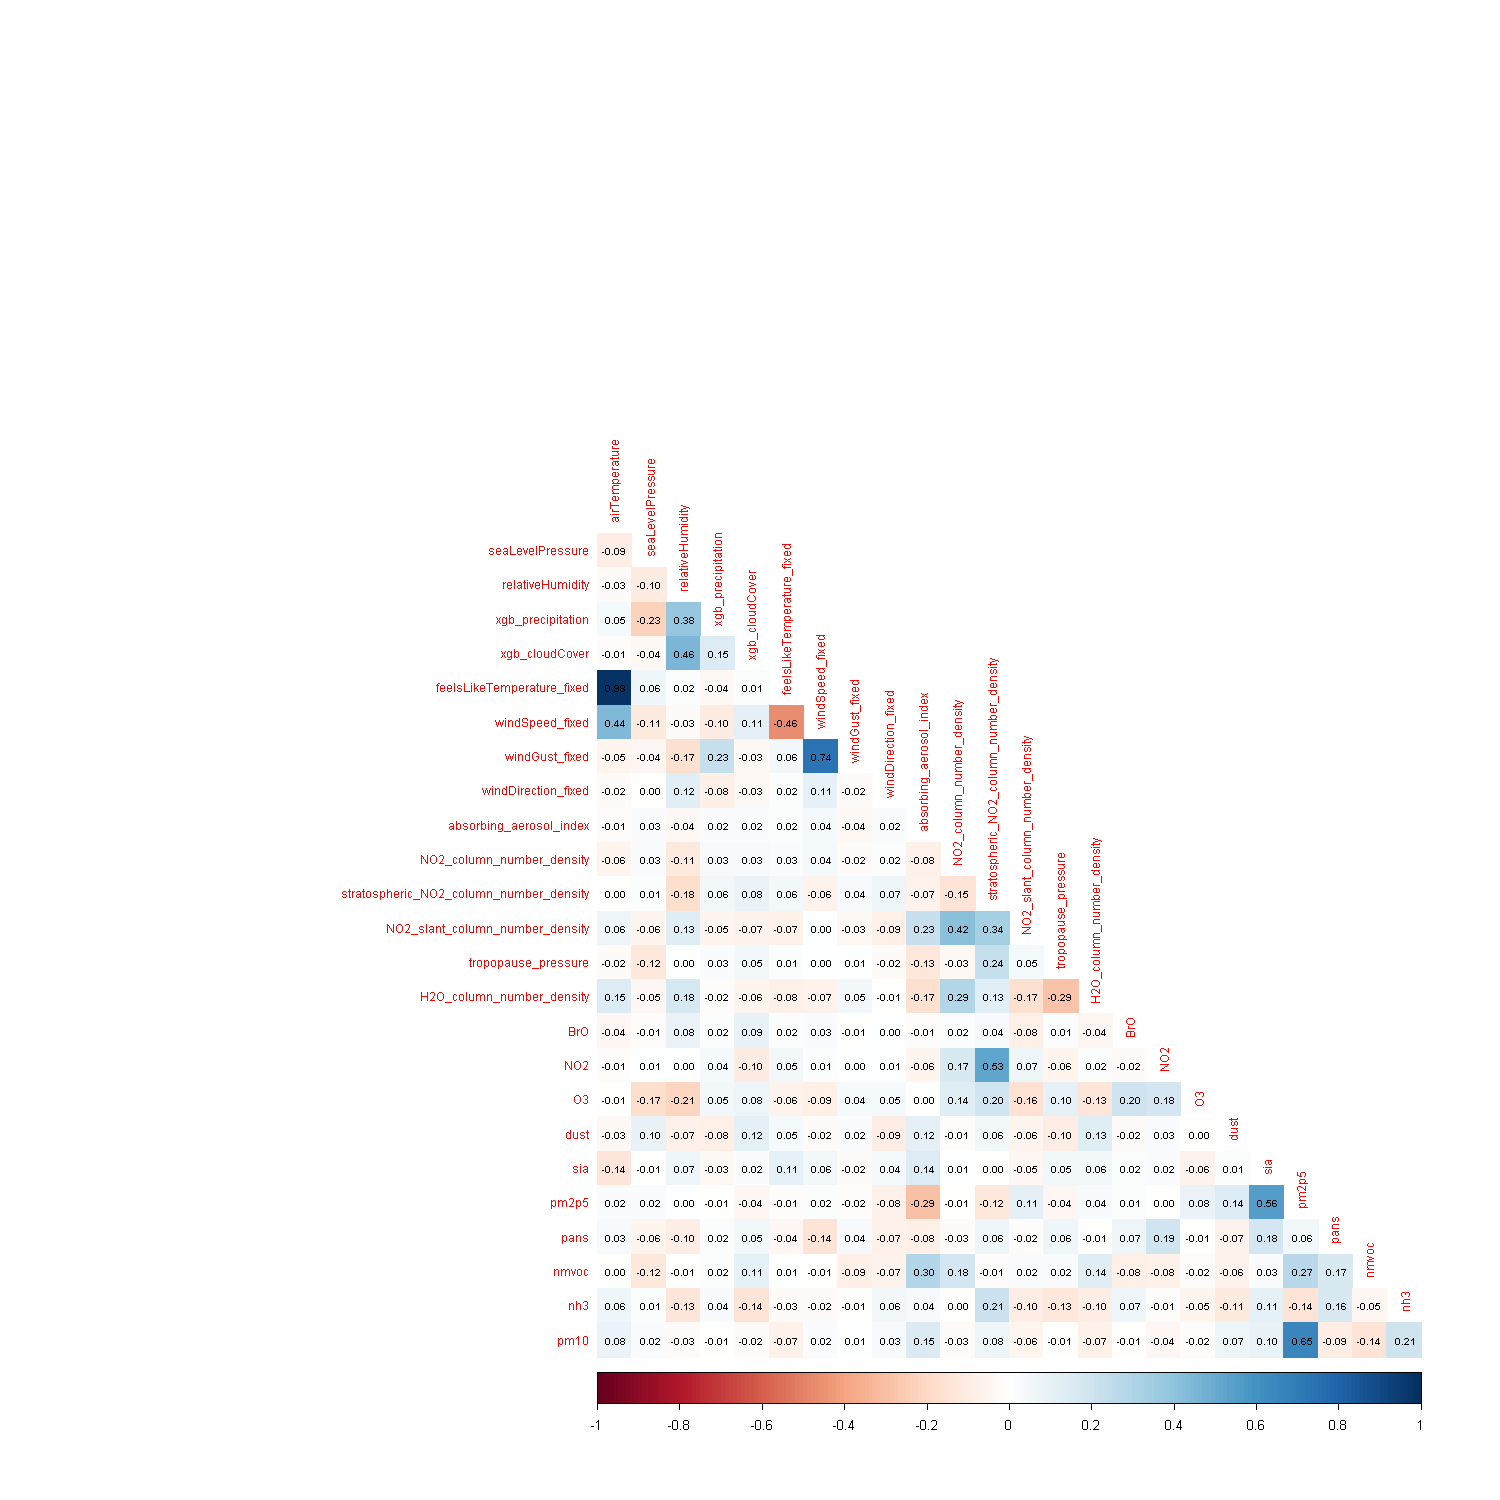

In [24]:
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 100)

corrplot(all_variables_pcor$estimate, method = "color", type = "lower", addCoef.col = "black", number.cex = 0.6, tl.cex = 0.7, diag = FALSE)

### Cross correlation

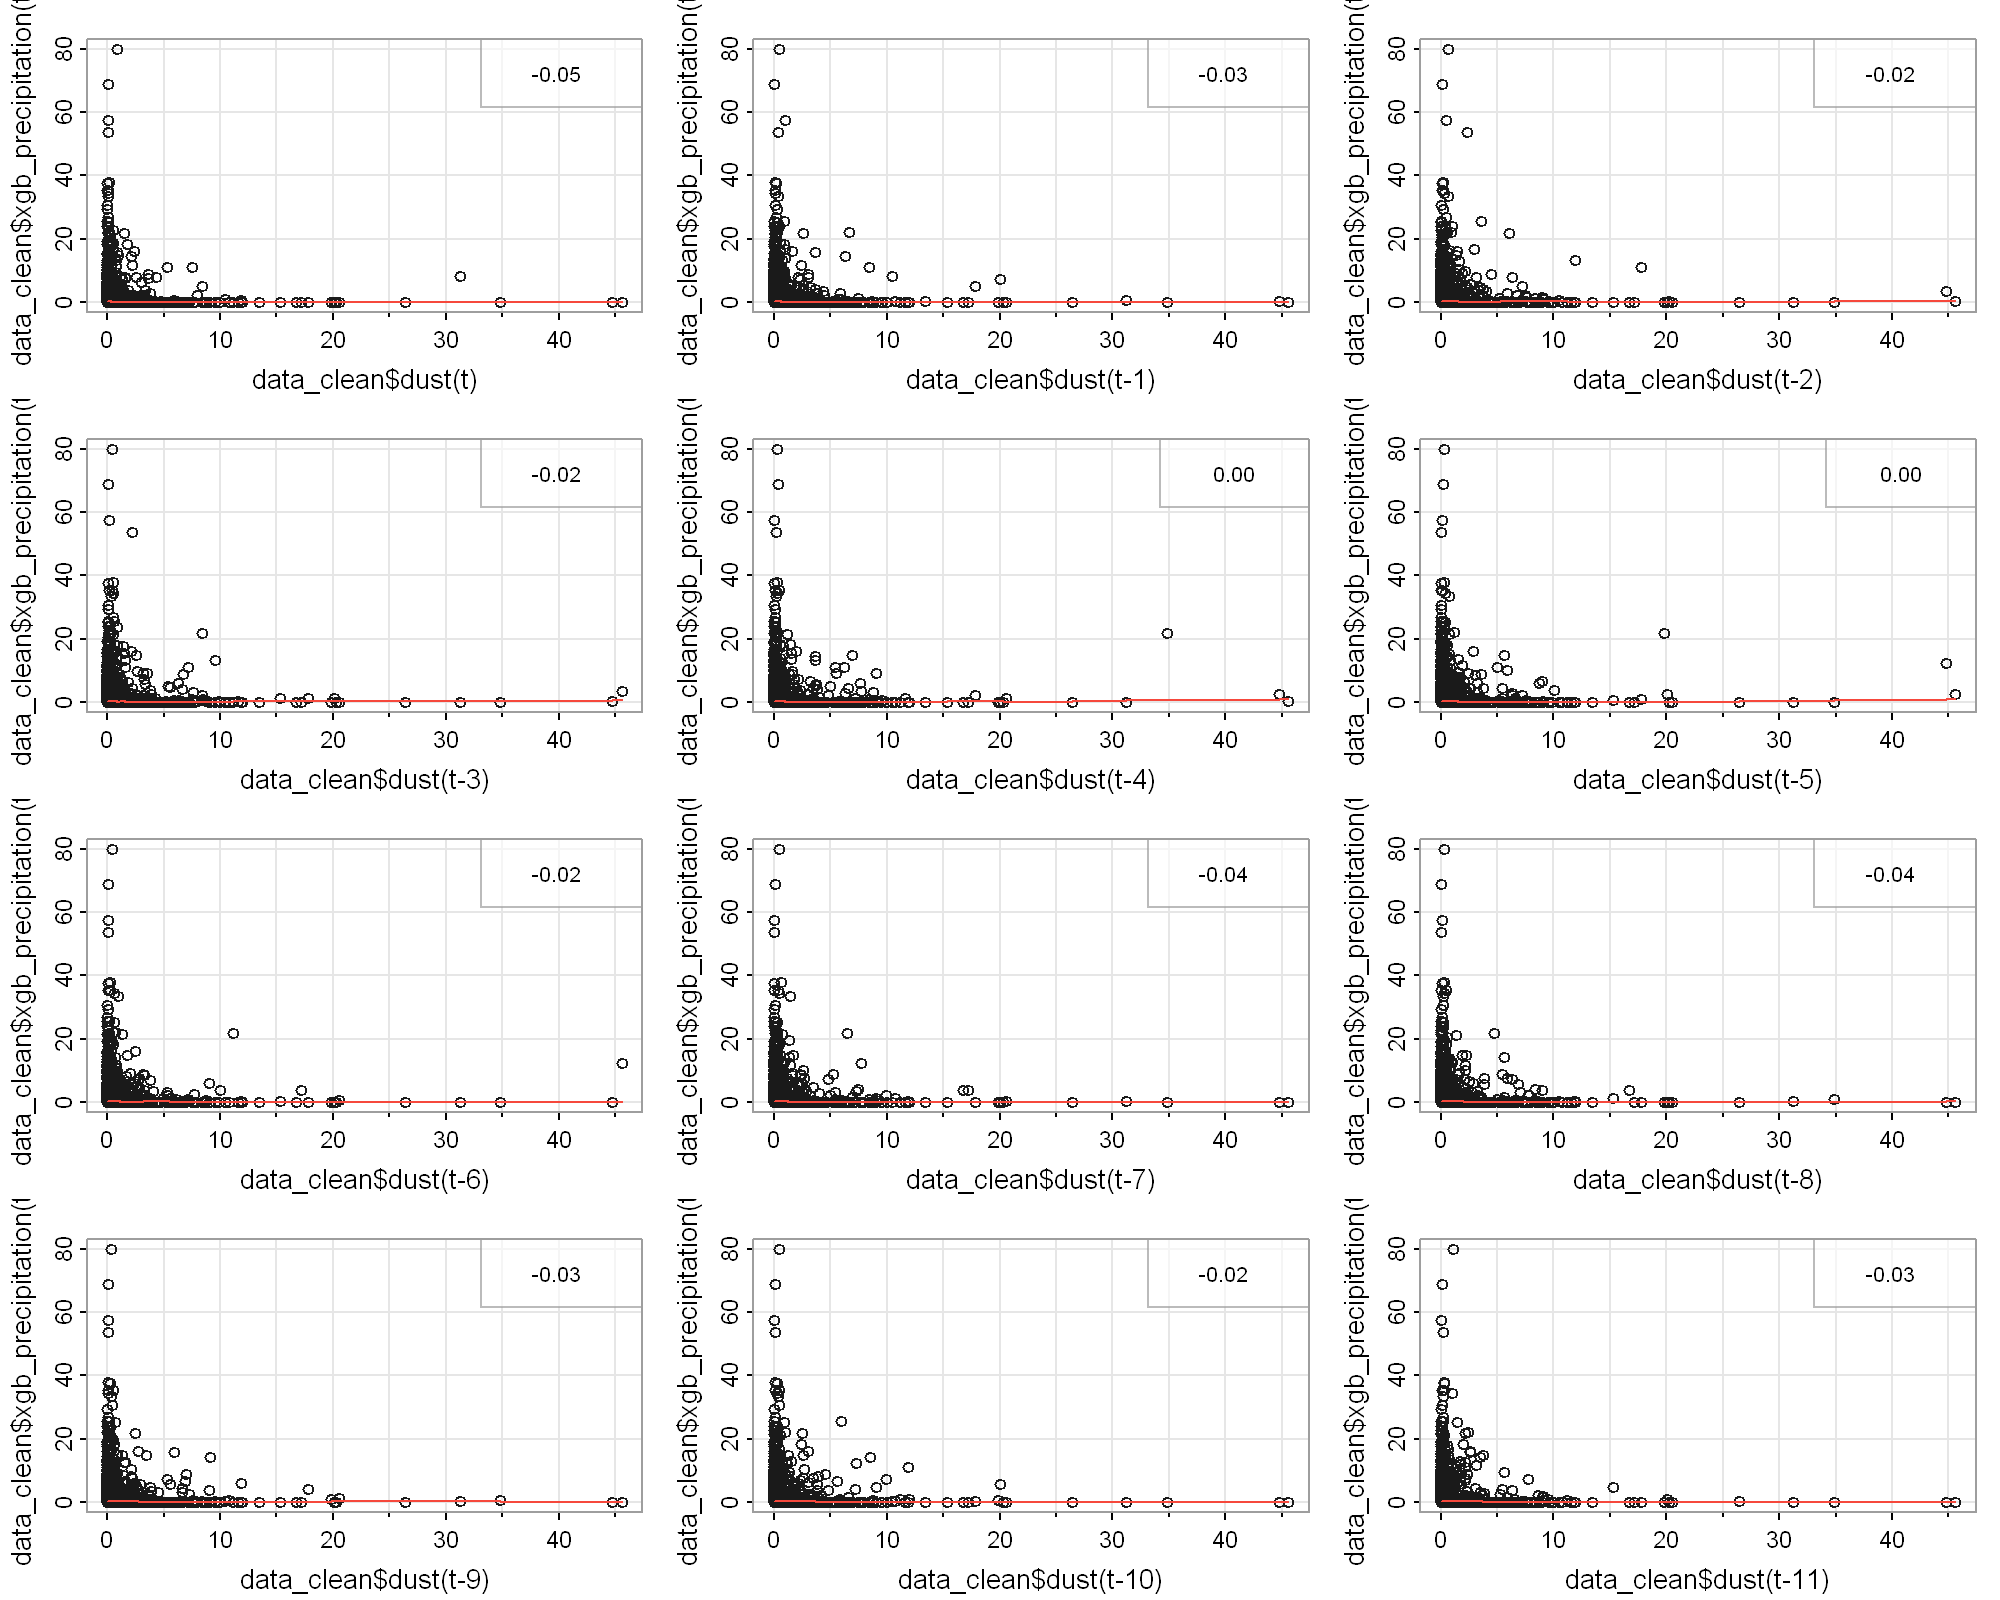

In [25]:
options(repr.plot.width = 10, repr.plot.height = 8, repr.plot.res = 200)

astsa::lag2.plot(data_clean$dust, data_clean$xgb_precipitation, 11)

In [26]:
colnames(data_clean)

[1] "time"                                   
 [2] "airTemperature"                         
 [3] "seaLevelPressure"                       
 [4] "relativeHumidity"                       
 [5] "xgb_precipitation"                      
 [6] "xgb_cloudCover"                         
 [7] "feelsLikeTemperature_fixed"             
 [8] "windSpeed_fixed"                        
 [9] "windGust_fixed"                         
[10] "windDirection_fixed"                    
[11] "absorbing_aerosol_index"                
[12] "NO2_column_number_density"              
[13] "stratospheric_NO2_column_number_density"
[14] "NO2_slant_column_number_density"        
[15] "tropopause_pressure"                    
[16] "H2O_column_number_density"              
[17] "BrO"                                    
[18] "NO2"                                    
[19] "O3"                                     
[20] "dust"                                   
[21] "sia"                                    
[22] "pm2p5"                                  
[23] "pans"                                   
[24] "nmvoc"                                  
[25] "nh3"                                    
[26] "pm10"                                   
[27] "tp"                                     
[28] "t2m"                                    
[29] "tp_lag"                                 
[30] "tp_error"

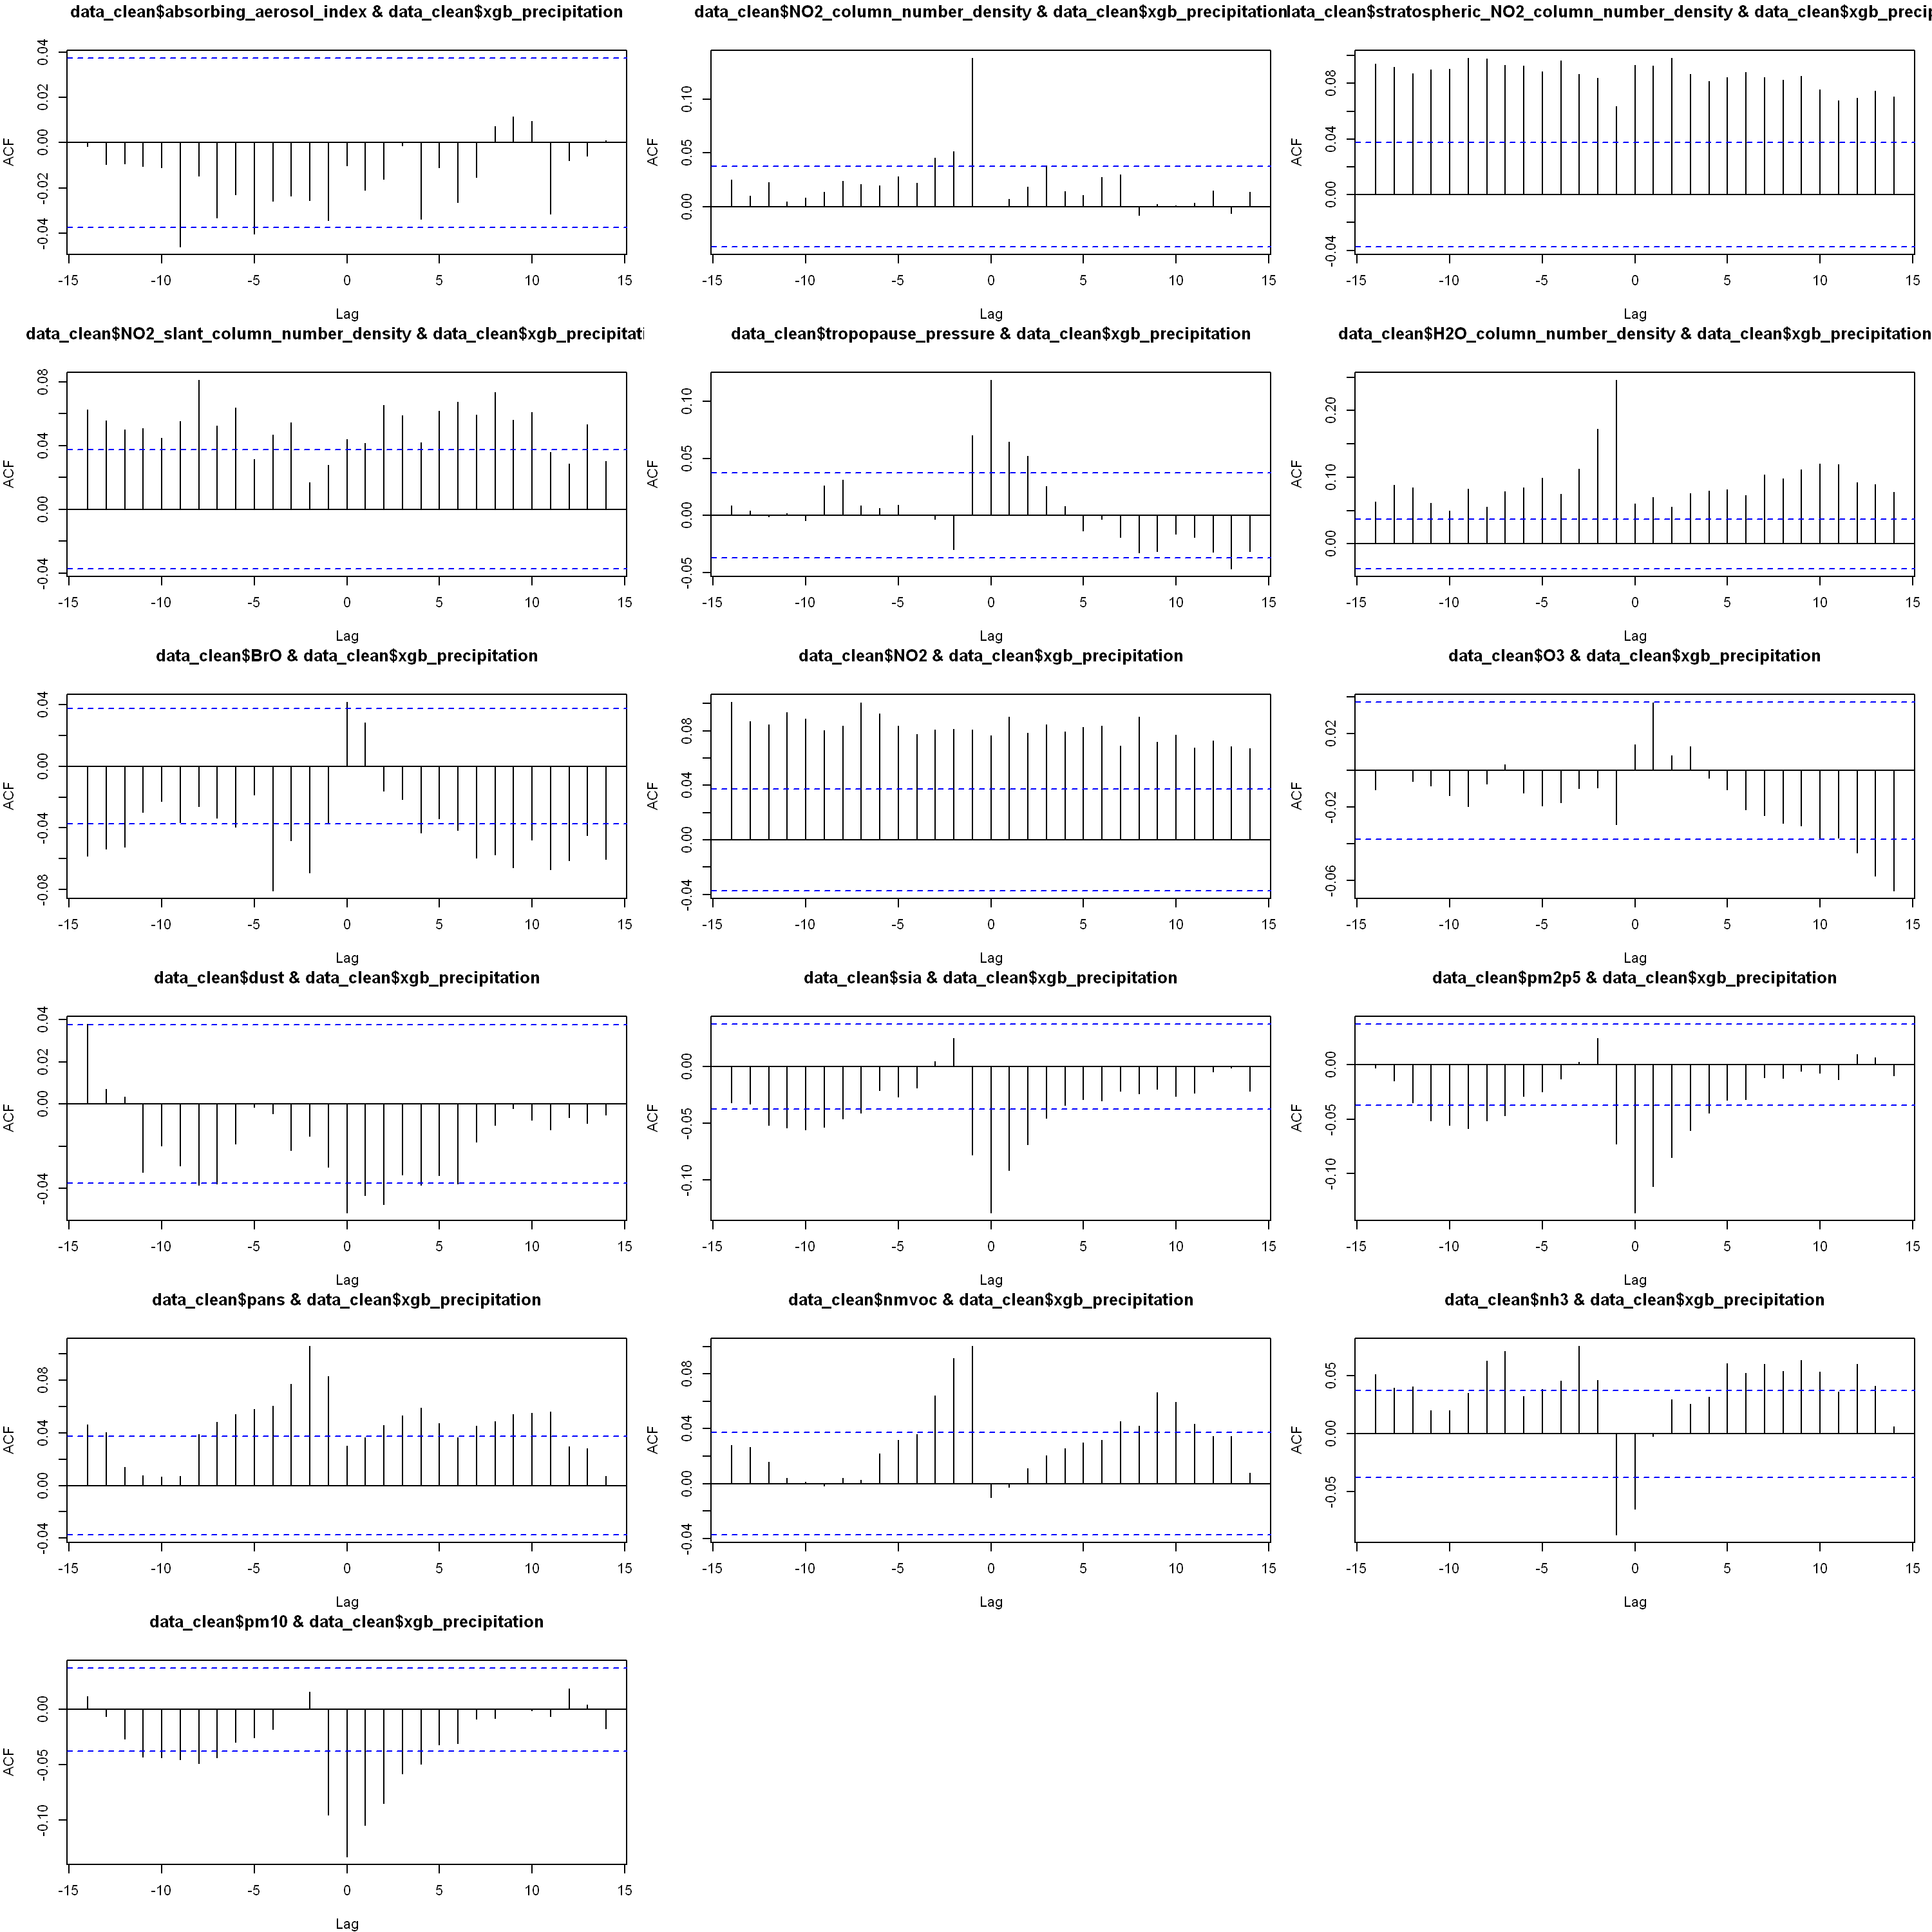

In [28]:
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 200)
par(mfrow = c(6, 3), mar = c(4, 4, 3, 1))

ccf(data_clean$absorbing_aerosol_index, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$NO2_column_number_density, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$stratospheric_NO2_column_number_density, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$NO2_slant_column_number_density, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$tropopause_pressure, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$H2O_column_number_density, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$BrO, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$NO2, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$O3, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$dust, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$sia, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$pm2p5, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$pans, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$nmvoc, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$nh3, data_clean$xgb_precipitation, lag.max = 14)
ccf(data_clean$pm10, data_clean$xgb_precipitation, lag.max = 14)

par(mfrow = c(1, 1))


Autocorrelations of series 'X', by lag

   -14    -13    -12    -11    -10     -9     -8     -7     -6     -5     -4 
 0.025  0.010  0.022  0.005  0.008  0.013  0.024  0.021  0.020  0.028  0.022 
    -3     -2     -1      0      1      2      3      4      5      6      7 
 0.046  0.052  0.139  0.001  0.007  0.018  0.038  0.014  0.011  0.027  0.030 
     8      9     10     11     12     13     14 
-0.008  0.002  0.001  0.004  0.015 -0.006  0.014 


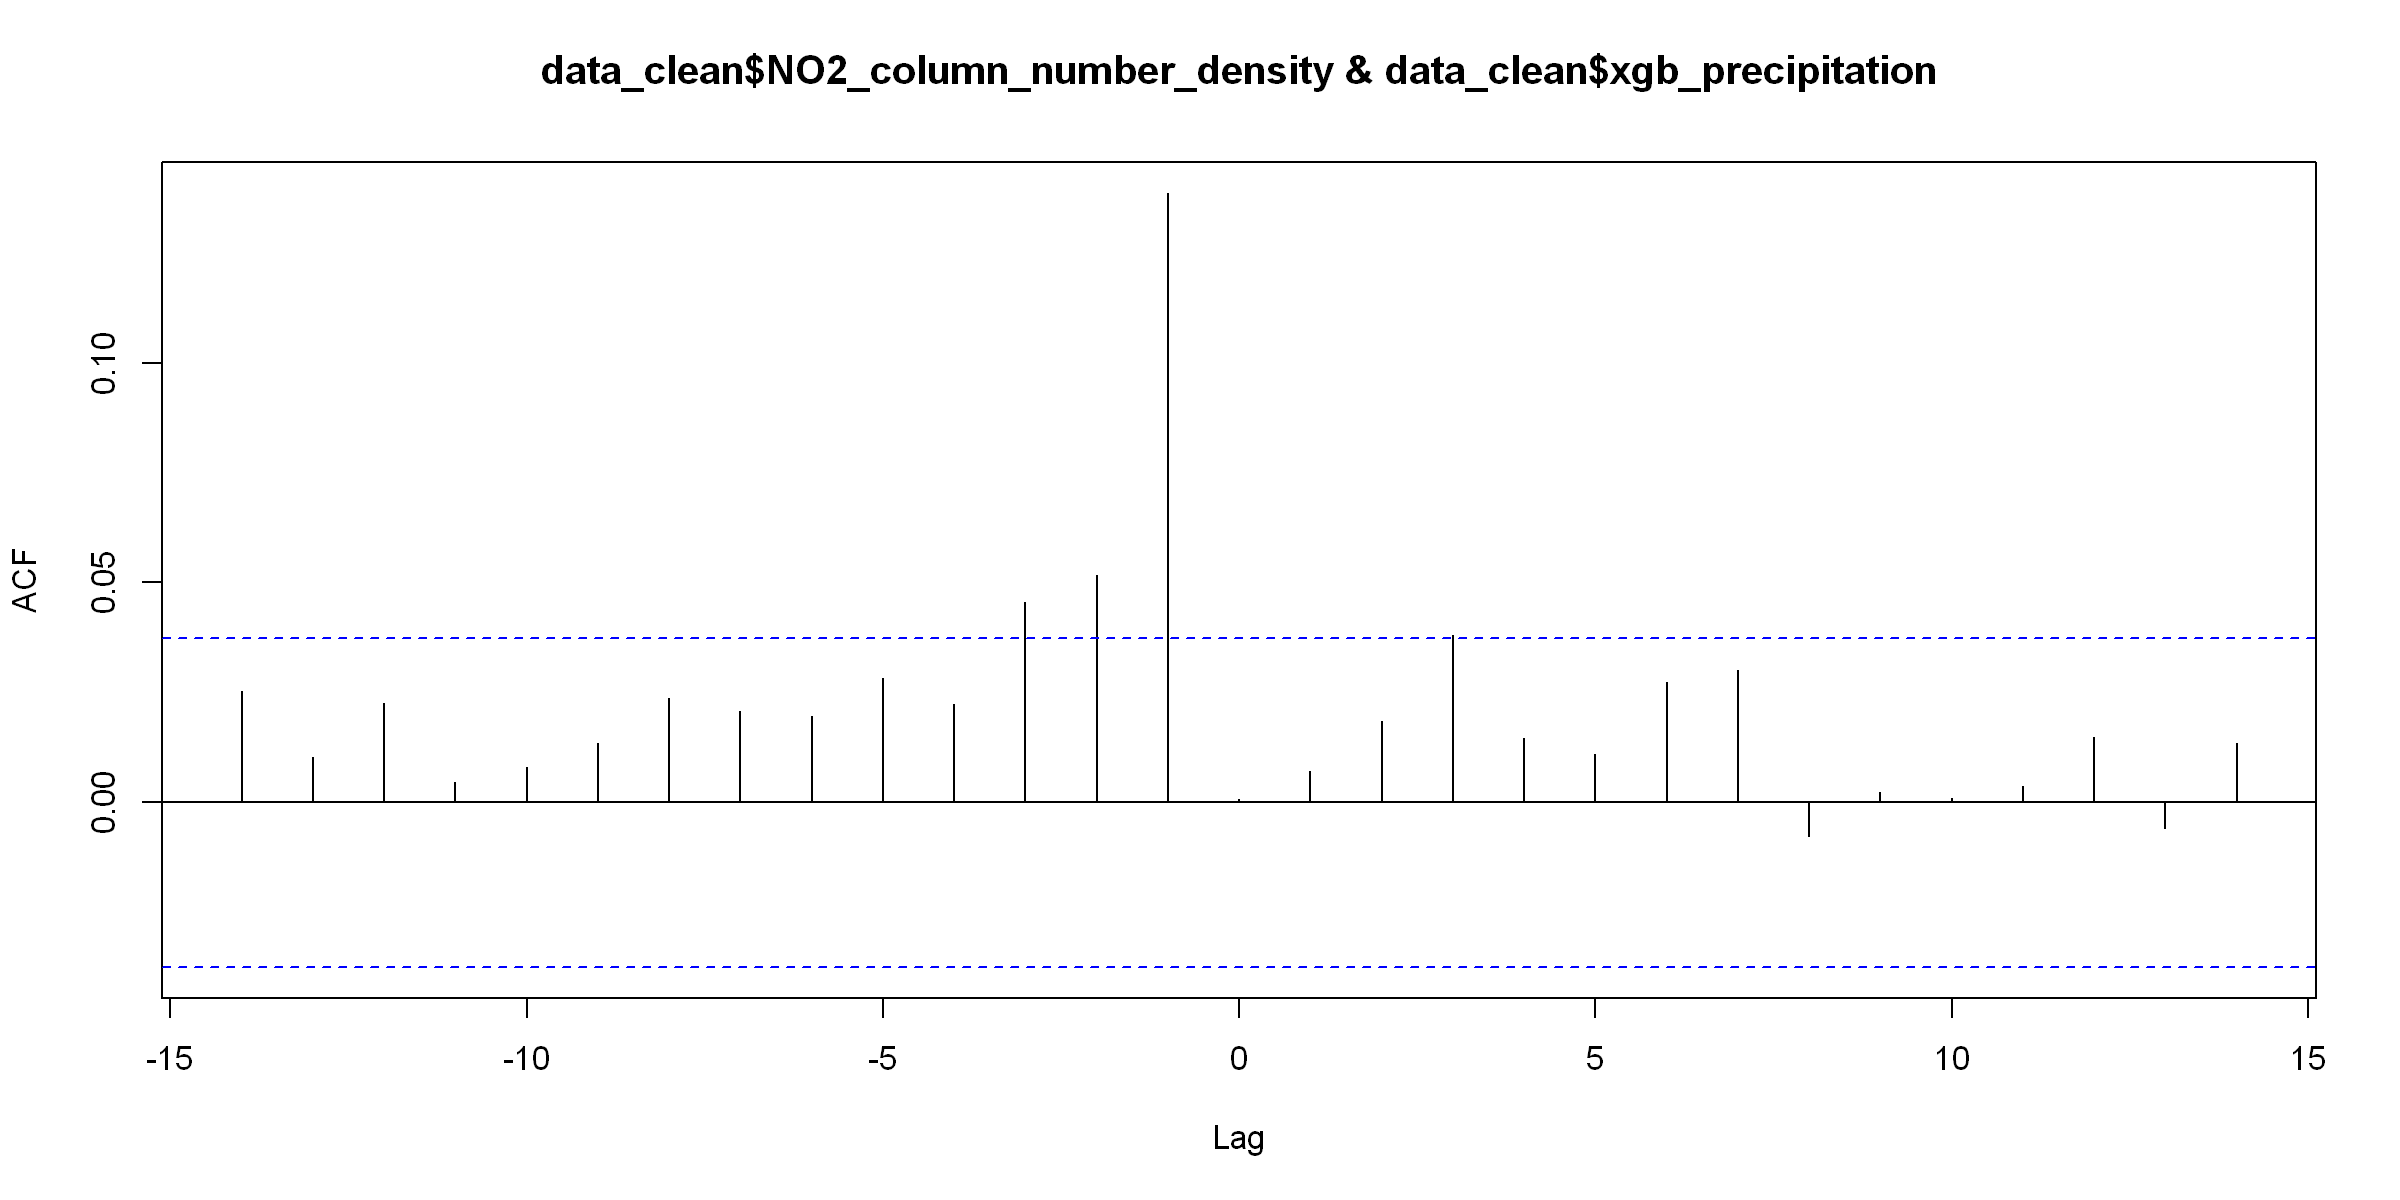

In [29]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)
print(ccf(data_clean$NO2_column_number_density, data_clean$xgb_precipitation, lag.max = 14))

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)

width_inch = 17 / 2.54
height_inch = width_inch * 0.75

png(filename = "cross_corr.png", width = width_inch, height = height_inch, units = "in", res = 300)
par(mfrow = c(3, 3), mar = c(3, 3, 3, 1), oma = c(2, 5, 4, 2))


plot_ccf_custom <- function(x, y, pavadinimas) {
  res <- ccf(x, y, lag.max = 14, plot = FALSE)
  
  plot(res, main = "", yaxt = 'n', ylab = "", cex.axis = 1, cex.lab = 1)
  title(main = pavadinimas, cex.main = 1.0)
  
  y_ticks <- axTicks(2)
  y_labels <- gsub("\\.", ",", sprintf("%.2f", y_ticks))

  axis(2, at = y_ticks, labels = y_labels, las = 1, cex.axis = 1)
}

plot_ccf_custom(data_clean$NO2_column_number_density, data_clean$xgb_precipitation, "NO2 VCD")
plot_ccf_custom(data_clean$BrO, data_clean$xgb_precipitation, "BrO VCD")
plot_ccf_custom(data_clean$H2O_column_number_density, data_clean$xgb_precipitation, "H2O")
plot_ccf_custom(data_clean$sia, data_clean$xgb_precipitation, "PM2,5 SIA")
plot_ccf_custom(data_clean$pm2p5, data_clean$xgb_precipitation, "PM2,5")
plot_ccf_custom(data_clean$pans, data_clean$xgb_precipitation, "PAN")
plot_ccf_custom(data_clean$nmvoc, data_clean$xgb_precipitation, "NMVO")
plot_ccf_custom(data_clean$nh3, data_clean$xgb_precipitation, "NH3")
plot_ccf_custom(data_clean$pm10, data_clean$xgb_precipitation, "PM10")

mtext("Kryžminės koreliacijos koeficientas", side = 2, line = 2, outer = TRUE, cex = 0.85)
mtext("Kryžminė koreliacija tarp kritulių ir taršos elementų", side = 3, line = 2, outer = TRUE, cex = 1.05)
par(mfrow = c(1, 1))

dev.off()

agg_record_1290329378 
                    2